# RAG - Retrieval Augmented Generation

# Large Language Models and Their Limitations

Large Language Models (LLMs) have **fundamentally transformed how we approach complex cognitive tasks**.  
They are now routinely used for:

- Writing production-ready code  
- Analyzing financial reports  
- Translating between dozens of languages  

Beyond text, **complementary foundation models** extend these capabilities to additional modalities, including:

- 👁️ Computer vision  
- 🗣️ Speech synthesis and recognition  
- 🎧 Audio processing  
- 🎨 Image generation  
- 🧠 Multimodal reasoning  

Most of these systems are built on **transformer-based architectures**, enabling them to process and generate human-like content across multiple domains.

---

## Structural Limitations of LLMs

Despite their impressive capabilities, these models have **fundamental structural limitations** that are important to understand.

### 🔒 No Access to Private Data
LLMs **do not have access to private, confidential, or proprietary data** unless it is explicitly provided by the user during interaction.

### 🧠 Limited Context Windows
Each model operates within a fixed **context window**, which constrains how much information it can consider at once.  
As a result:
- Very long documents may be expensive or impossible to analyze in a single pass
- Information outside the window is effectively forgotten

### 🎭 Hallucinations Under Uncertainty
When relevant information is missing or ambiguous, LLMs may:
- Generate plausible-sounding but incorrect responses
- Hallucinate facts rather than explicitly admitting uncertainty

Understanding these limitations is critical for **responsible, effective, and reliable use** of large language models in real-world applications.

## Retrieval-Augmented Generation (RAG)

**Retrieval-Augmented Generation (RAG)** addresses all three of the core limitations of large language models at once.

It enables the model to:

- 🔎 Access **external knowledge sources** in a controlled way  
- 📚 Work with **far more information** than can fit into a single prompt  
- 🧱 Ground responses in **retrieved evidence** rather than guesswork  

---

## How RAG Works

When a user asks a question, a RAG-based system follows a two-stage process:

1. **Retrieval**  
   Relevant information is fetched from an external knowledge source  
   (e.g., documents, databases, vector stores).

2. **Generation**  
   The retrieved context is injected into the prompt and passed to the language model,  
   which generates a response grounded in that evidence.

---

By separating **knowledge retrieval** from **language generation**, RAG systems produce answers that are more:
- Accurate  
- Up-to-date  
- Explainable  
- Trustworthy  

This makes RAG a powerful architecture for applications such as question answering, enterprise search, technical assistants, and domain-specific AI systems.

## Interpreting a Basic RAG Architecture


At a high level, a RAG system consists of two primary components:

- **Retriever**  
  The retriever searches a knowledge source—such as a vector store or a traditional database—and returns passages that are relevant to the user’s query.

  You can think of a vector store as a *specialized search engine* that indexes **your own documents and knowledge base**, rather than the entire web like Google.

- **Generator**  
  The generator, typically a large language model (LLM), consumes the retrieved material and uses it to produce a **grounded, context-aware answer**.

---

## When RAG Is Most Useful

RAG is particularly effective in scenarios where:

- Knowledge is distributed across many documents  
- Answers require **synthesis**, not simple keyword lookup  
- The data is too large, complex, or diverse for a human to review manually  

---

## Beyond the Simplest Form

Modern RAG systems often go beyond a single retriever. They may employ:

- One retriever for unstructured documents  
- Another for structured databases  
- Additional tools that call external APIs  

The language model acts as a **coordinator**, deciding which tools to invoke and how to combine their outputs to answer each question effectively.

This modular design makes RAG systems flexible, extensible, and well-suited for real-world knowledge-intensive applications.

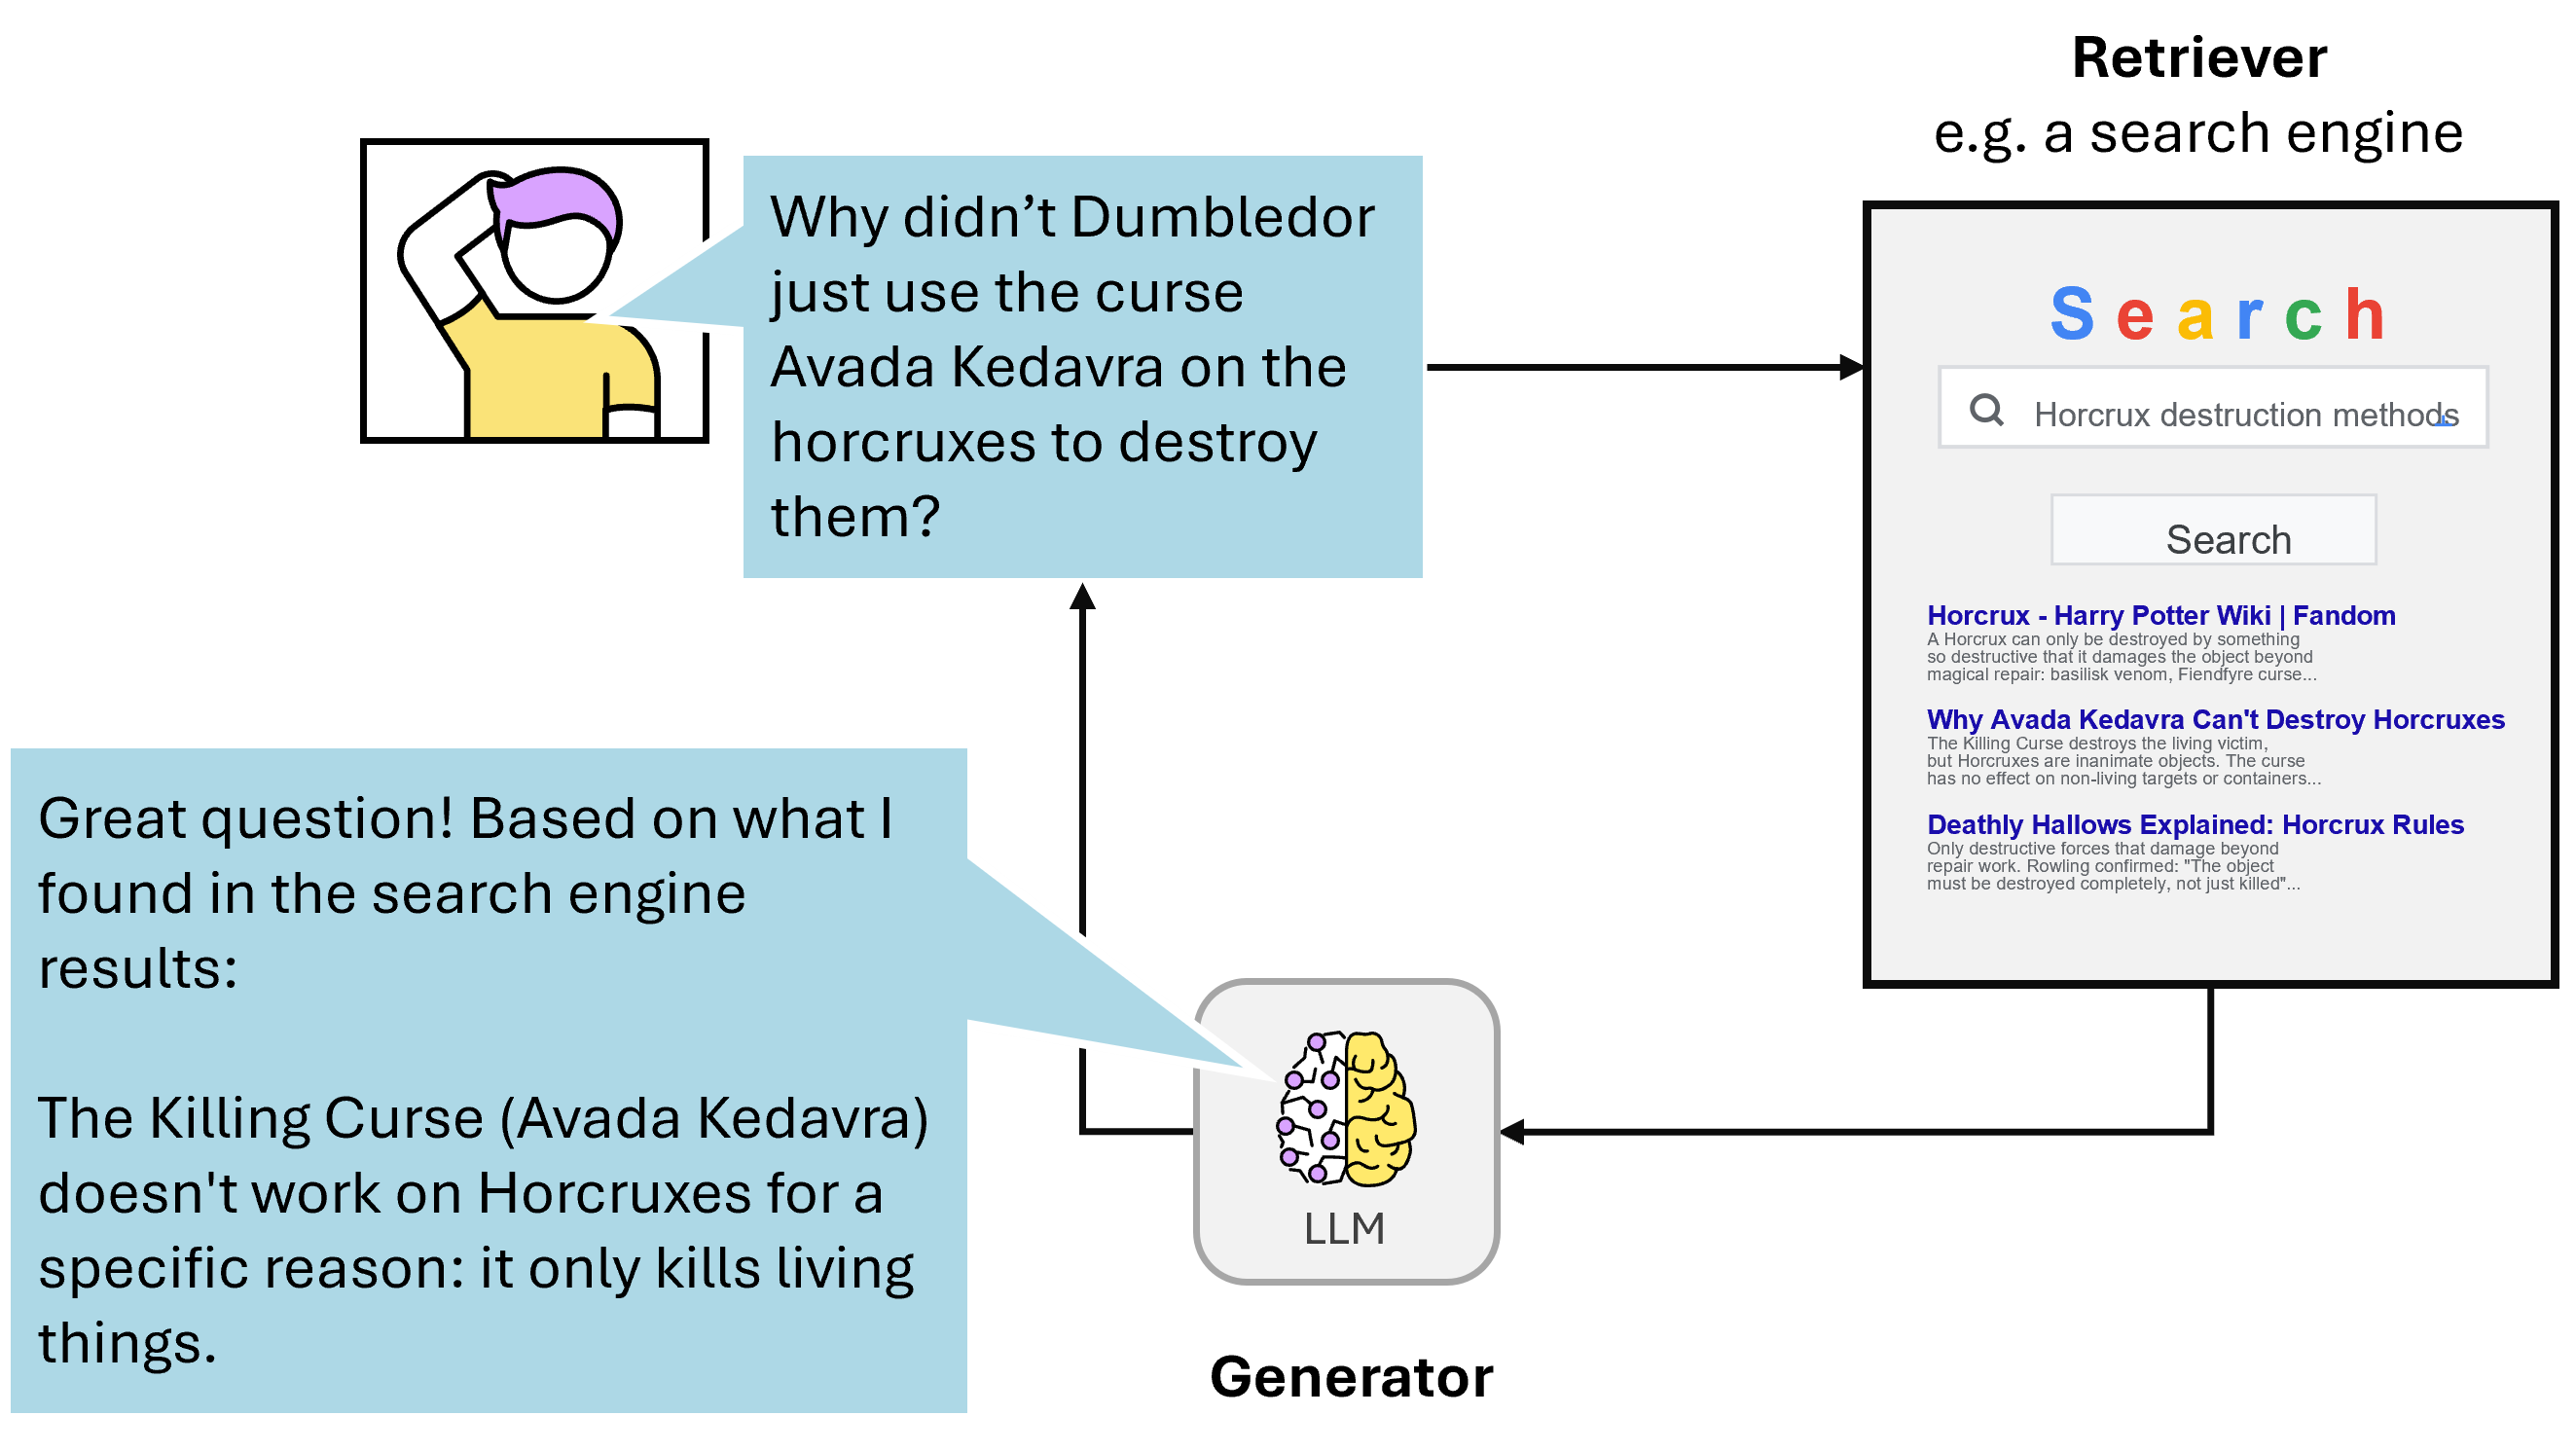

In [5]:
from IPython.display import Image, display

display(Image(filename="images/rwpc_0101.png", width=500, height=500))

## RAG Code

## Install Required Packages

In [2]:
%pip install "numpy<2" openai==1.12.0 chromadb==0.4.22 tiktoken==0.5.2 python-dotenv==1.0.0

### Load secrets

If you run this code in Google Colab, save your OpenAI API key in the secrets and access it by

### Storing Secrets and API Keys

In [3]:
import os
import sys
from dotenv import load_dotenv

# Check if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    try:
        from google.colab import userdata  # type: ignore

        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
        os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
        os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
    except ModuleNotFoundError:
        pass
else:
    load_dotenv()

### Load secrets

If you run this code in Google Colab, save your OpenAI API key in the secrets and access it by

In [5]:
import os

if IN_COLAB:
    from google.colab import userdata  # type: ignore

    api_key = userdata.get("OPENAI_API_KEY")

    if not api_key:
        raise ValueError("OPENAI_API_KEY not found in Colab Secrets")

    os.environ["OPENAI_API_KEY"] = api_key

## Building Your First RAG App

You want to get started and build your first RAG based conversational knowledge chatbot. <br>
Every RAG system is built around three essential components:

- An embedding model that represents text as vectors
- A vector store that searches those vectors
- An LLM that generates answers from retrieved context

## Workflow

## End-to-End RAG Workflow

A Retrieval-Augmented Generation (RAG) system typically follows a two-phase workflow: **data ingestion** and **query processing**.

---


## Data Ingestion

Before the system can answer questions, documents must be prepared and indexed.

The ingestion process consists of the following steps:

1. **Split documents into smaller chunks**  
   Large documents are broken into manageable pieces to improve retrieval accuracy and context relevance.

2. **Generate embeddings for each chunk**  
   Each chunk is converted into a vector representation that captures its semantic meaning.

3. **Store vectors in a vector database**  
   These embeddings are stored in a vector database optimized for similarity search.

---

## Query Processing

When a user submits a question, the system performs the following steps:

1. **Convert the user’s question into an embedding vector**  
   The query is embedded using the same embedding model used during ingestion.

2. **Search the vector database for the closest matching vectors**  
   A similarity search retrieves chunks that are semantically related to the question.

3. **Select the most relevant chunks**  
   The top-ranked results are chosen as contextual evidence.

4. **Send the selected chunks together with the user’s question to the LLM**  
   Both the query and retrieved context are passed to the language model.


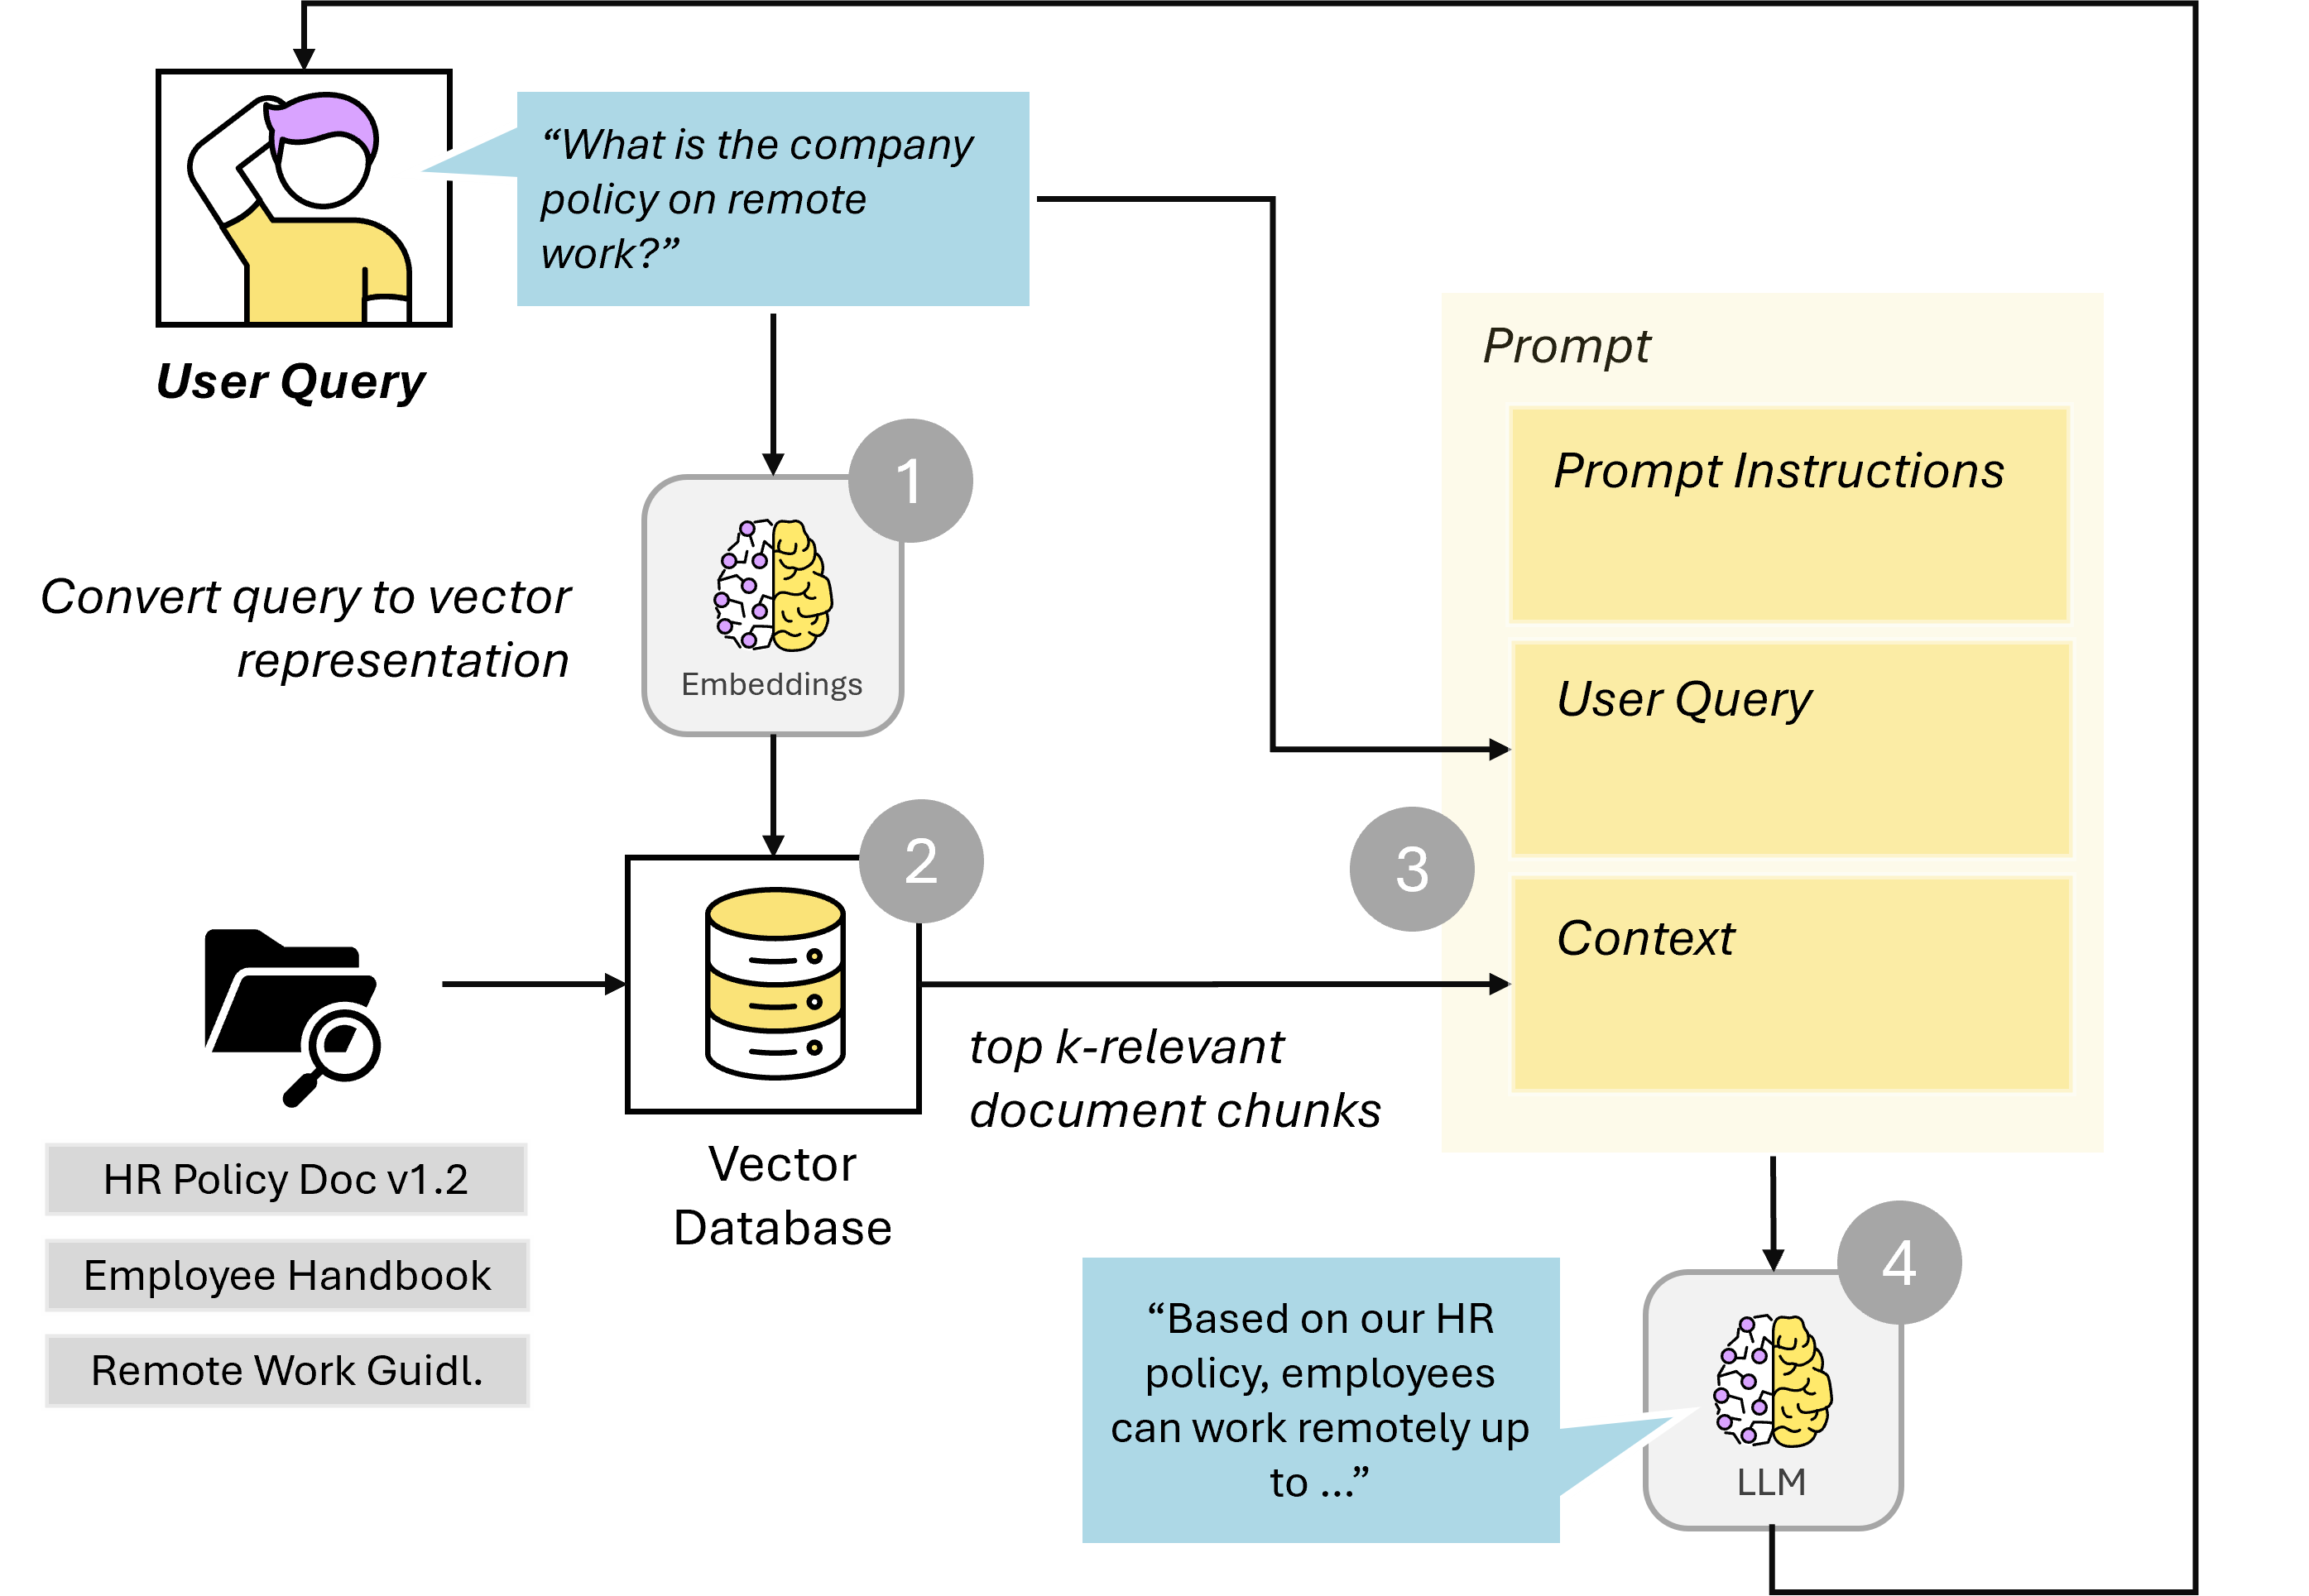

In [7]:
from IPython.display import Image, display

display(Image(filename="images/rwpc_0107.png", width=500, height=500))

In the last step, the LLM generates an answer using this context.

#### Before you begin, make sure you have the following:

OpenAI account and API key from OpenAI Platform

ChromaDB for vector storage 

This recipe demonstrates the workflow by building a Harry Potter knowledge chatbot. 
the overall architecture this recipe implements. 
The retriever searches a ChromaDB vector store built from the Harry Potter books, 
and the generator uses OpenAI models to answer questions based on retrieved context.

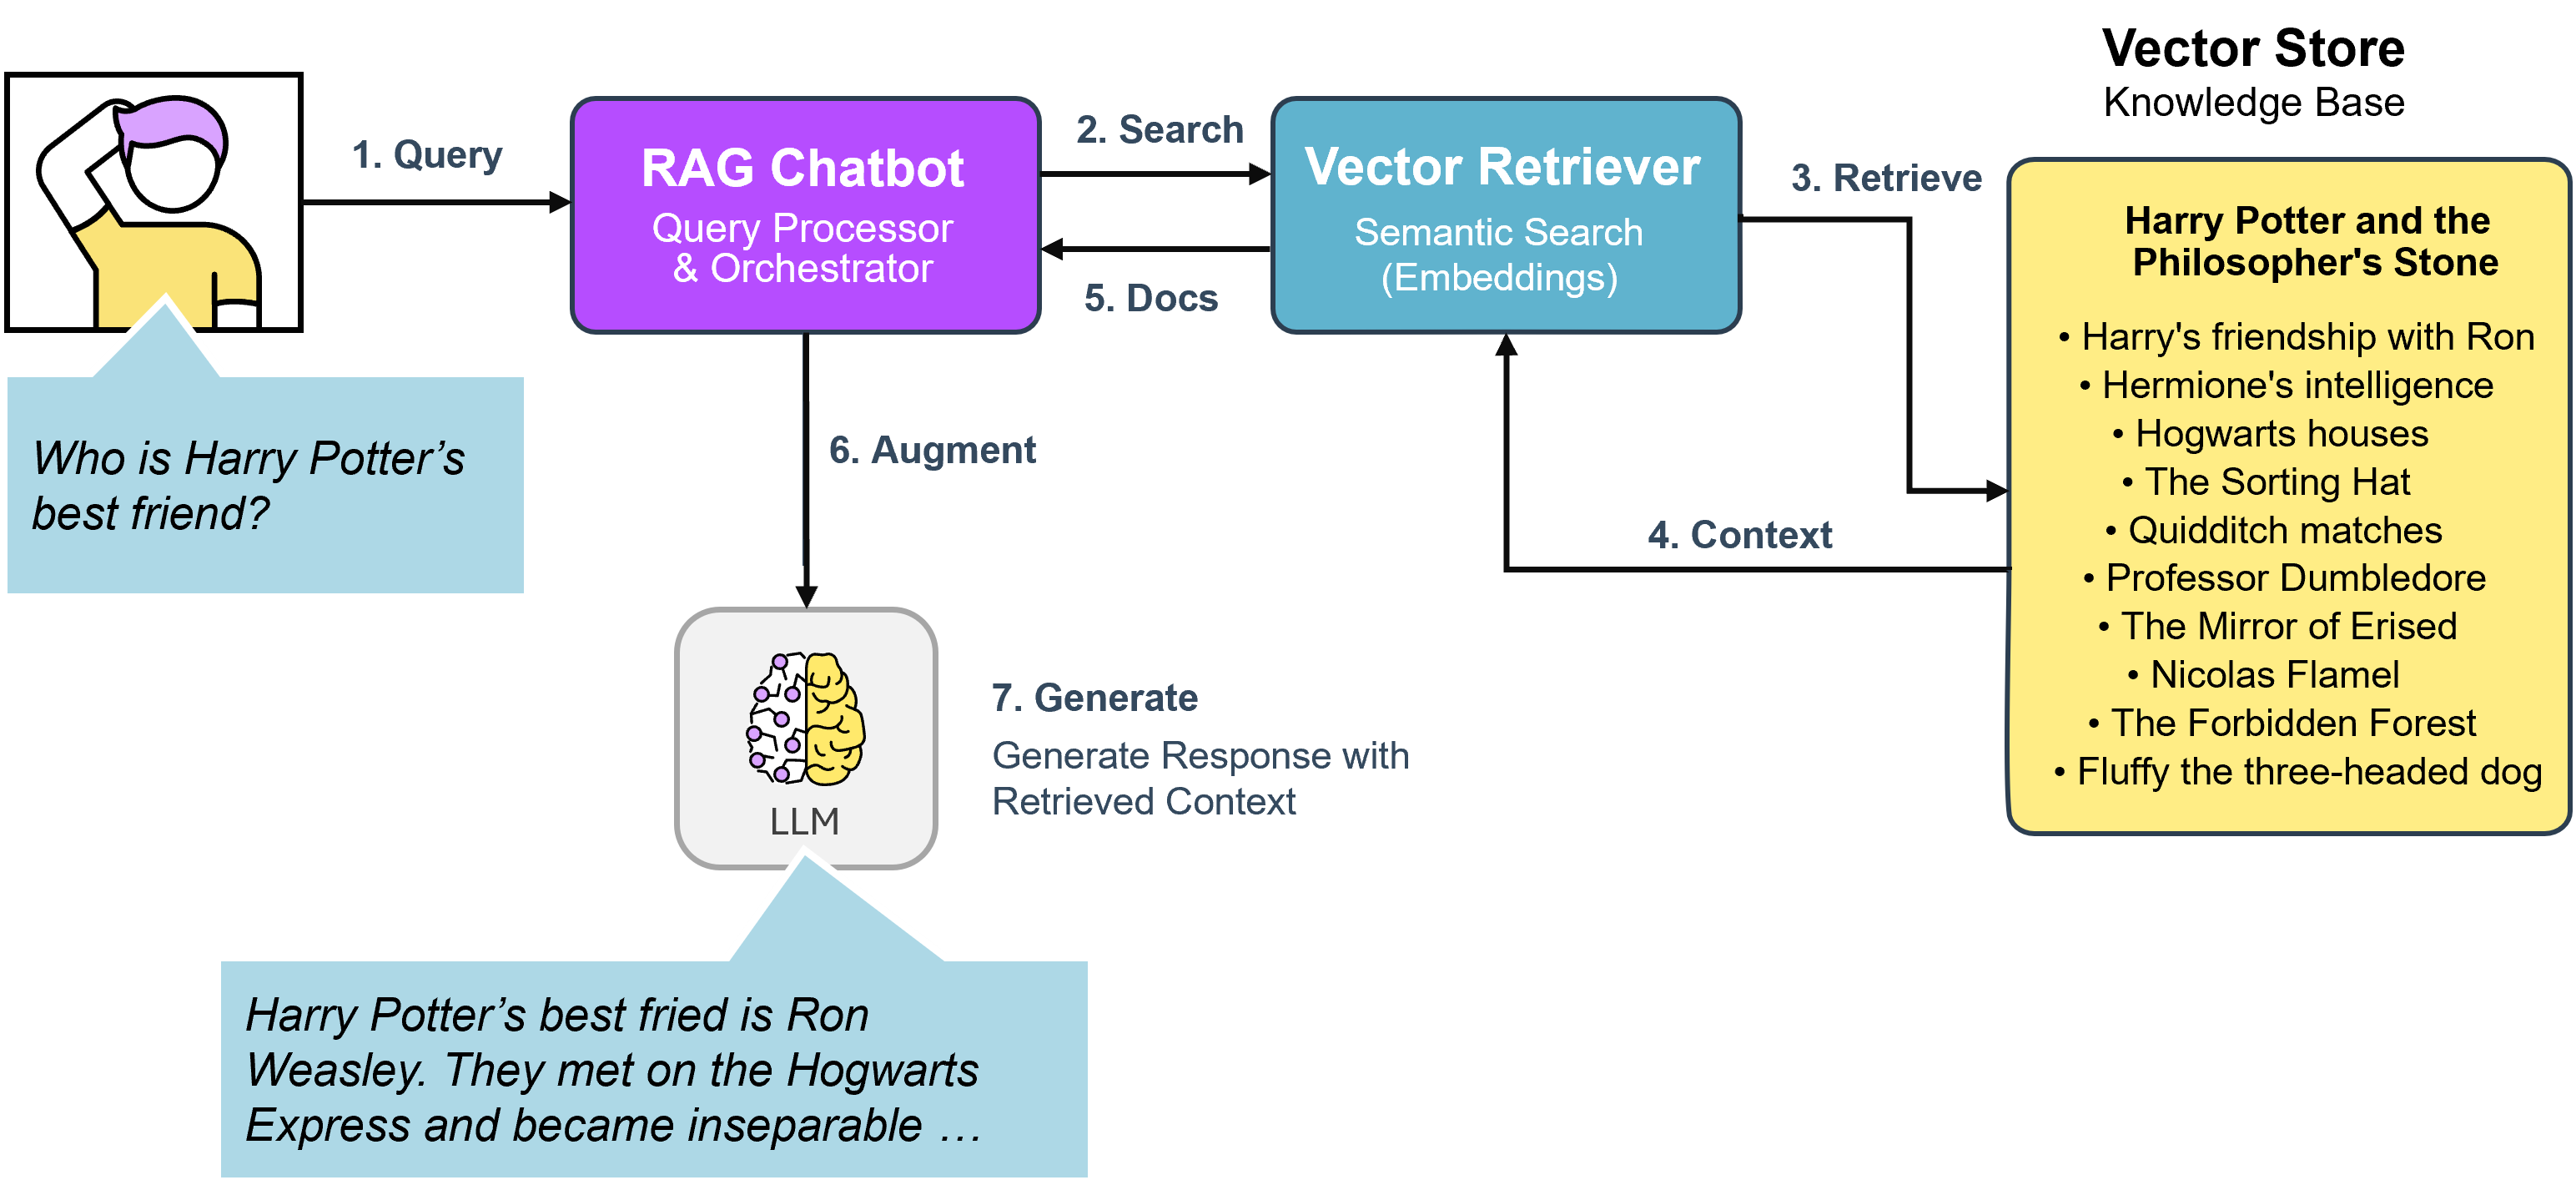

In [10]:
display(Image(filename="images/rwpc_0108.png", width=600, height=600))

## Step 1: Text Chunking

This example builds RAG from scratch without frameworks to demonstrate how simple the core concepts are. RAG orchestration frameworks like LangChain and LlamaIndex provide ready-to-use chunking functions, but this example avoids those dependencies to keep the implementation lightweight and the core concepts clear.<br>
Split documents into smaller chunks with overlap to preserve context. <br>
The following code demonstrates how to chunk text at natural boundaries, such as paragraphs or sentences, with overlap to preserve context across chunks.

In [8]:
# Import Path to work with file paths in an OS-independent way
from pathlib import Path

# Import ChromaDB (used later for vector storage)
import chromadb

# Import OpenAI client (used later for embeddings / LLM calls)
from openai import OpenAI


# Function to split a long text into smaller overlapping chunks
def chunk_text(text, size=1000, overlap=200):
    # List to store all text chunks
    chunks = []
    
    # Starting index for slicing the text
    start = 0

    # Loop until we reach the end of the text
    while start < len(text):
        # Tentative end index for the chunk
        end = min(start + size, len(text))

        # If we are not at the very end of the text
        if end < len(text):
            # Try to split at a paragraph boundary first
            bp = text.rfind("\n\n", start, end)

            # If no paragraph break is found, try sentence boundary
            if bp == -1:
                bp = text.rfind(". ", start, end)

            # If a suitable break point is found, adjust the end index
            if bp > start:
                end = bp + 1

        # Extract the chunk and remove leading/trailing whitespace
        chunk = text[start:end].strip()

        # Only add non-empty chunks
        if chunk:
            chunks.append(chunk)

        # Move the start forward, keeping overlap with the previous chunk
        # Overlap helps preserve context between chunks
        start = end - overlap if end < len(text) else end

    # Return the list of text chunks
    return chunks


# Path to the knowledge base text file
file_path = Path("./datasets/text_files/harry_potter_knowledge_base.txt")

# Read the entire text file into a string
text = file_path.read_text(encoding="utf-8")

# Split the text into overlapping chunks
chunks = chunk_text(text)

#### Why this matters (quick intuition)

- Chunking prevents long documents from exceeding model context limits
- Overlap ensures important context isn’t lost between chunks
- Clean boundaries (paragraphs/sentences) improve embedding quality and retrieval accuracy

## Step 2: Embed and Store in ChromaDB

Generate embeddings and store them in a vector database.

In [14]:
# Import httpx to create a custom HTTP client
# This is recommended for better connection handling with the OpenAI client
import httpx  

# Create an OpenAI client using httpx as the HTTP backend
client = OpenAI(http_client=httpx.Client())

# Specify the embedding model to convert text into vectors
embedding_model = "text-embedding-3-small"


# Function to generate embeddings for text chunks and store them in ChromaDB
def embed_and_store(chunks, db_path, collection_name):
    # Create (or connect to) a persistent ChromaDB client
    # The database will be stored on disk at the given path
    chroma = chromadb.PersistentClient(path=str(db_path))

    # Get an existing collection or create a new one if it doesn't exist
    collection = chroma.get_or_create_collection(
        name=collection_name,
        metadata={"description": "Harry Potter knowledge base"},
    )

    # List to store all generated embeddings
    embeddings = []

    # Process chunks in batches of 100 to avoid API limits
    for i in range(0, len(chunks), 100):
        # Select a batch of up to 100 text chunks
        batch = chunks[i : i + 100]

        # Send the batch to the OpenAI API to generate embeddings
        res = client.embeddings.create(
            model=embedding_model,
            input=batch
        )

        # Extract the embedding vectors from the response
        embeddings.extend([x.embedding for x in res.data])

    # Store the chunks, embeddings, and metadata in the ChromaDB collection
    collection.add(
        # Unique IDs for each chunk
        ids=[f"chunk_{i}" for i in range(len(chunks))],

        # Original text chunks
        documents=chunks,

        # Corresponding embedding vectors
        embeddings=embeddings,

        # Metadata to track the original chunk index
        metadatas=[{"chunk_index": i} for i in range(len(chunks))],
    )

    # Return the collection for later querying
    return collection


# Directory where the ChromaDB database will be stored
chroma_db_dir = Path("chroma_db")

# Generate embeddings and store them in the vector database
collection = embed_and_store(
    chunks,
    chroma_db_dir,
    "harry_potter_kb"
)

# Display the collection object
collection

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Collection(name=harry_potter_kb)

### Big-picture intuition 🧠
- Each text chunk → embedding vector
- Embeddings are stored in ChromaDB for fast similarity search
- Metadata keeps track of where each chunk came from
This prepares your data so it can be retrieved later during user queries

## Step 3: Test Retrieval

Test that the retrieval system finds relevant chunks for a given question.

In [13]:
# Function to retrieve the most relevant text chunks for a user question
def retrieve(question, top_k=3):
    # Convert the user's question into an embedding vector
    # This uses the same embedding model as was used for the documents
    q_emb = client.embeddings.create(
        model=embedding_model,
        input=question,
    ).data[0].embedding

    # Query the ChromaDB collection using the question embedding
    res = collection.query(
        # Provide the embedding to search with
        query_embeddings=[q_emb],

        # Number of most similar chunks to return
        n_results=top_k,

        # Specify that we want the original document text back
        include=["documents"],
    )

    # ChromaDB returns a list of lists (one list per query)
    # Since we asked one question, we take the first list of documents
    return res["documents"][0]


# Example user question
question = "Why did Uncle Vernon take the family to a hut in the middle of the sea?"

# Retrieve the most relevant chunks from the vector database
docs = retrieve(question)

# Display the retrieved text chunks
docs

["dozen, then by the hundred. They came through the chimney, through cracks in the door, even delivered by owls. Uncle Vernon tried everything to stop them, but the letters found Harry wherever he was.\n\nFinally, in a desperate attempt to escape the letters, Uncle Vernon drove the family to a hut on a rock in the middle of the sea. On the stroke of midnight on Harry's eleventh birthday, there was a tremendous bang on the door, and it was blasted open by Hagrid, the giant gamekeeper from Hogwarts. Hagrid was furious to discover that the Dursleys had never told Harry about his magical heritage, about his parents' true fate, or about his acceptance to Hogwarts School of Witchcraft and Wizardry.",
 "Little Whinging, Surrey. There was no stamp, and when Harry turned it over, he saw a purple wax seal bearing a coat of arms with a lion, an eagle, a badger, and a snake surrounding a large letter H.\n\nBefore Harry could open it, Uncle Vernon snatched it away. After reading it, his face went f

- The question is embedded into a vector
- That vector is used to search the vector database
- The top-k most similar text chunks are returned
- These chunks will later be passed to the LLM as context

## Step 4: Test Generation

Feed the retrieved documents and question to the LLM to generate an answer.

In [12]:
# Function to generate an answer using retrieved documents as context
def answer(question, docs):
    # Combine all retrieved text chunks into a single context string
    # The separator makes boundaries between chunks clear for the LLM
    context = "\n\n---\n\n".join(docs)

    # Construct the prompt that strictly instructs the model
    # to answer using only the provided context
    prompt = f"""Answer the question using only the context below.

Context:
{context}

Question:
{question}

Answer:"""

    # Send the prompt to the OpenAI chat completion API
    res = client.chat.completions.create(
        # Lightweight model suitable for fast RAG responses
        model="gpt-5-mini",

        # Single user message containing the full prompt
        messages=[{"role": "user", "content": prompt}],
    )

    # Extract and return the generated answer text
    return res.choices[0].message.content


# Example user question
question = "Why did Uncle Vernon take the family to a hut in the middle of the sea?"

# Retrieve relevant document chunks
docs = retrieve(question)

# Generate a grounded answer using the retrieved context
answer_text = answer(question, docs)

# Display the final answer
answer_text

'Because dozens—then hundreds—of letters addressed to Harry kept arriving no matter what Vernon did, so he drove the family to a hut on a rock in the middle of the sea to escape the letters.'

- Retrieved chunks are stitched together into a context block
- The prompt explicitly restricts the model to that context
- The LLM generates an answer grounded in retrieved evidence
- This completes the full RAG loop:
       Retrieve → Augment → Generate

### At this point, you’ve built a fully working RAG system 🎉